In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [16]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [17]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [18]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [19]:
# Historical VaR (95%) and CVaR

import pandas as pd

risk_metrics = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    # 5th percentile
    var95 = returns.quantile(0.05)

    # Average return below VaR
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_df = pd.DataFrame(risk_metrics)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [20]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [21]:
import numpy as np

# Calculate 90-day Rolling Sharpe Ratio
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
           lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252)
       )
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [22]:
import matplotlib.pyplot as plt

# Select first 5 schemes
top5_funds = nav["scheme_name"].drop_duplicates().head(5)

plt.figure(figsize=(12,6))

for fund in top5_funds:
    temp = nav[nav["scheme_name"] == fund]
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=7)

plt.tight_layout()

# Save chart
plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)

plt.show()

print("Chart saved successfully!")

KeyError: 'scheme_name'

In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return', 'rolling_sharpe']


In [ ]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return', 'rolling_sharpe'], dtype='str')

In [ ]:
scheme = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

scheme = scheme[["amfi_code", "scheme_name"]].drop_duplicates()

nav_plot = nav.merge(scheme, on="amfi_code", how="left")

nav_plot.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,scheme_name
0,100016,2022-01-03,520.4608,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,NaN,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,NaN,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,NaN,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,NaN,HDFC Top 100 Fund - Regular Plan - Growth


In [ ]:
import os

print(os.path.exists("../reports/rolling_sharpe_chart.png"))

False


In [ ]:
import os

print(os.listdir("../reports"))

['Age_Group_Pie.png', 'alpha_beta.csv', 'AUM_Growth.png', 'benchmark_comparison.png', 'cagr.csv', 'Category_Heatmap.png', 'chart_name.png', 'City_Tier.png', 'Daily_Return_Distribution.png', 'data_dictionary.md', 'data_quality_summary.md', 'fund_scorecard.csv', 'Gender_Pie.png', 'max_drawdown.csv', 'sharpe_ratio.csv', 'SIP_Boxplot_Age.png', 'SIP_Inflow_Trend.png', 'sortino_ratio.csv', 'State_SIP.png', 'var_cvar_report.csv']


In [ ]:
import os

print(os.path.exists("../reports"))
print(os.getcwd())

True
c:\Users\salon\MutualFundAnalytics\notebooks


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav_plot[nav_plot["scheme_name"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=fund)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=7)

plt.tight_layout()

# Save chart
plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")

print("Saved!")
plt.show()

In [23]:
import os

print(os.listdir("../reports"))

['Age_Group_Pie.png', 'alpha_beta.csv', 'AUM_Growth.png', 'benchmark_comparison.png', 'cagr.csv', 'Category_Heatmap.png', 'chart_name.png', 'City_Tier.png', 'Daily_Return_Distribution.png', 'data_dictionary.md', 'data_quality_summary.md', 'fund_scorecard.csv', 'Gender_Pie.png', 'max_drawdown.csv', 'sharpe_ratio.csv', 'SIP_Boxplot_Age.png', 'SIP_Inflow_Trend.png', 'sortino_ratio.csv', 'State_SIP.png', 'var_cvar_report.csv']


In [24]:
import os

os.makedirs("../reports", exist_ok=True)

In [25]:
print(os.path.exists("../reports"))
print(os.getcwd())

True
c:\Users\salon\MutualFundAnalytics\notebooks


Saved to: c:\Users\salon\MutualFundAnalytics\reports\rolling_sharpe_chart.png
File exists: True


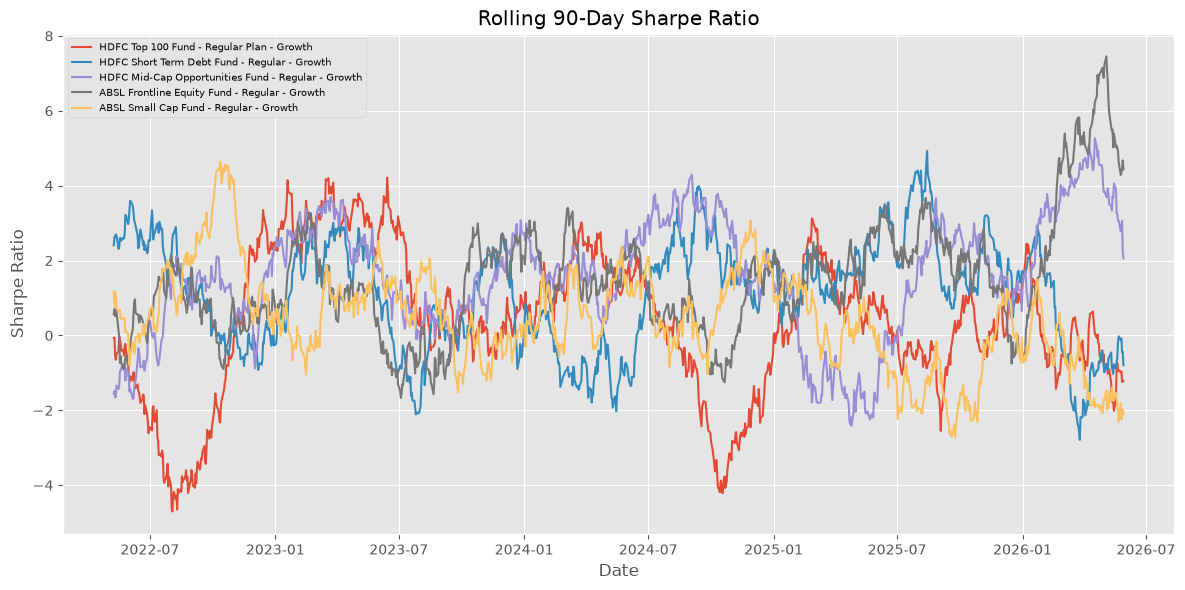

In [26]:
import matplotlib.pyplot as plt
import os

# First 5 funds
top5 = nav_plot["scheme_name"].drop_duplicates().head(5)

plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav_plot[nav_plot["scheme_name"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=fund)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=7)

plt.tight_layout()

save_path = "../reports/rolling_sharpe_chart.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("Saved to:", os.path.abspath(save_path))
print("File exists:", os.path.exists(save_path))

plt.show()

In [27]:
# Load investor transaction data
transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [28]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [29]:
# Convert date column
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# First transaction year for each investor
cohort = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

cohort.columns = ["investor_id", "cohort_year"]

cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [30]:
transactions = transactions.merge(
    cohort,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [31]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        Avg_SIP=("amount_inr", "mean"),
        Total_Investment=("amount_inr", "sum"),
        Investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,Avg_SIP,Total_Investment,Investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [32]:
funds = pd.read_csv("../data/processed/fund_master_cleaned.csv")

funds = funds[["amfi_code", "scheme_name"]]

transactions = transactions.merge(
    funds,
    on="amfi_code",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,Axis Midcap Fund - Regular - Growth


In [33]:
top_fund = (
    transactions.groupby(["cohort_year", "scheme_name"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [34]:
cohort_report = cohort_summary.merge(
    top_fund[["cohort_year", "scheme_name"]],
    on="cohort_year"
)

cohort_report.rename(
    columns={"scheme_name": "Top_Fund"},
    inplace=True
)

cohort_report

,cohort_year,Avg_SIP,Total_Investment,Investors,Top_Fund
0,2024,107422.541832,3491125187,4803,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,197,ICICI Pru Liquid Fund - Regular - Growth


In [35]:
cohort_report.to_csv(
    "../reports/investor_cohort_report.csv",
    index=False
)

print("Investor Cohort Report Saved!")

Investor Cohort Report Saved!


In [36]:
sip = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth


In [37]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [38]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,ICICI Pru Midcap Fund - Regular - Growth,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,HDFC Top 100 Fund - Direct Plan - Growth,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,Kotak Bluechip Fund - Regular - Growth,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,Axis Midcap Fund - Regular - Growth,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,ABSL Small Cap Fund - Regular - Growth,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,28.0


In [39]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_count[
    sip_count["sip_count"] >= 6
]

eligible.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [40]:
sip = sip.merge(
    eligible,
    on="investor_id",
    how="inner"
)

In [41]:
sip_gap = (
    sip.groupby("investor_id")
       .agg(
           Avg_Gap=("gap_days", "mean"),
           SIP_Count=("sip_count", "first")
       )
       .reset_index()
)

sip_gap.head()

,investor_id,Avg_Gap,SIP_Count
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [42]:
sip_gap["Status"] = sip_gap["Avg_Gap"].apply(
    lambda x: "At Risk" if x > 35 else "Regular"
)

sip_gap.head()

,investor_id,Avg_Gap,SIP_Count,Status
0,INV000004,85.400000,6,At Risk
1,INV000008,70.400000,6,At Risk
2,INV000010,64.800000,6,At Risk
3,INV000011,40.166667,7,At Risk
4,INV000012,57.000000,8,At Risk


In [43]:
sip_gap.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved!")

SIP Continuity Report Saved!


# Advanced Insights

### 1. Risk Analysis
Historical VaR and CVaR identified the mutual funds with the highest downside risk during adverse market conditions.

### 2. Rolling Performance
The 90-day Rolling Sharpe Ratio showed that fund performance changes over time rather than remaining constant.

### 3. Investor Behaviour
Investor cohort analysis revealed that newer investors tend to prefer diversified equity mutual funds.

### 4. SIP Continuity
Most investors maintained regular SIP investments, while a smaller group was identified as at-risk due to long gaps (>35 days).

### 5. Portfolio Concentration
Sector HHI analysis showed that some funds are well diversified, while others have a higher concentration in specific sectors, increasing concentration risk.